## Experiment Tutorial: Multiple Measurements

In [13]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit_layer
from qsopt.core.gates import RXGate, RYGate, RZGate
from qsopt.core.experiment.experiment import Experiment

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [14]:
# Define experimental parameters using nested configuration objects
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm
n_qubits = 3

interaction = [QubitInteraction(
    qubit_indices=(i, j),
    interaction_type=InteractionType.XX,
    chi=0.1
) for i in range(n_qubits) for j in range(n_qubits) if i!=j ]

physical_constants = PhysicalConstants(
    n_qubits=n_qubits,
    chi=30.0,
    photon_cavity_coupling=15.0,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=interaction
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=2
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, -4.0, 0, 4.0, 8.0])/inverse_pulse_width)
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=0.0001,
    dephasing=0.0001,
    relaxation=0.0001
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          3
  Cavity levels:             2
  Qubit levels:         [2, 2, 2]
  Field levels:              2
  Total dimension:          32
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    0.0188
  Qubit interactions:   6 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
    [1] Qubits (0, 2): sx-sx, χ=0.1000
    [2] Qubits (0, 1): sx-sx, χ=0.1000
    [3] Qubits (1, 2): sx-sx, χ=0.1000
    [4] Qubits (0, 2): sx-sx, χ=0.1000
    [5] Qubits (1, 2): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      5
  Measurement times:    [-424.4131815783876, -212.2065907891938, 0.0, 212.2065907891938, 424.4131815783876]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001, 0.0001, 0.0001]
  Dephasing rate:       [0.0001, 0.0001, 0.0001]
  Relaxation rate:      [0.0001, 0.0001, 0.0001]
  Custom 

## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [15]:
# Create Circuit with 4 rotation angles

initial_circuit = create_ry_circuit_layer(n_qubits=n_qubits, theta_values=np.pi/2)
for i in range(n_qubits):
    initial_circuit.add_gate(RZGate(theta=np.pi/3, target=i, trainable=True))

final_circuit = create_ry_circuit_layer(n_qubits=n_qubits, theta_values=-np.pi/2)

print(initial_circuit)
print(final_circuit)

QuantumCircuit(3 qubits, 6 gates)
  0: RY(1.5708)[0][0]
  1: RY(1.5708)[1][1]
  2: RY(1.5708)[2][2]
  3: RZ(1.0472)[0][0]
  4: RZ(1.0472)[1][1]
  5: RZ(1.0472)[2][2]
QuantumCircuit(3 qubits, 3 gates)
  0: RY(-1.5708)[0][0]
  1: RY(-1.5708)[1][1]
  2: RY(-1.5708)[2][2]


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [16]:
experiment = Experiment(exp_params, initial_circuit, final_circuit)

## 4. Run Basic Simulation

In [17]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1)

print(callback)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
        param_2: 1.570796 rad (90.00°)
        param_3: 1.047198 rad (60.00°)
        param_4: 1.047198 rad (60.00°)
        param_5: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
        param_2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.981012
     P(without photon): 0.976921
     Contrast:          0.004091


## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [19]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=150,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=10,
    initial_values=[np.pi/3, np.pi/4, np.pi/4, np.pi/3, np.pi/3, np.pi/3, -np.pi/3, -np.pi, -np.pi/4],
    renormalize_grad=False
)


Configuration:
    Max iterations: 150
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: any excited
    Trainable parameters: 9 (6 initial circuit + 3 final circuit)
    Initial parameter values:
        param0. setup_=1.047 rad (60.0°)
        param1. setup_=0.785 rad (45.0°)
        param2. setup_=0.785 rad (45.0°)
        param3. setup_=1.047 rad (60.0°)
        param4. setup_=1.047 rad (60.0°)
        param5. setup_=1.047 rad (60.0°)
        param6. reset_=-1.047 rad (-60.0°)
        param7. reset_=-3.142 rad (-180.0°)
        param8. reset_=-0.785 rad (-45.0°)
Step  setup_0     setup_1     setup_2     setup_3     reset_0     reset_1     reset_2     Contrast    Grad Norm
---------------------------------------------------------------------------


KeyboardInterrupt: 

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


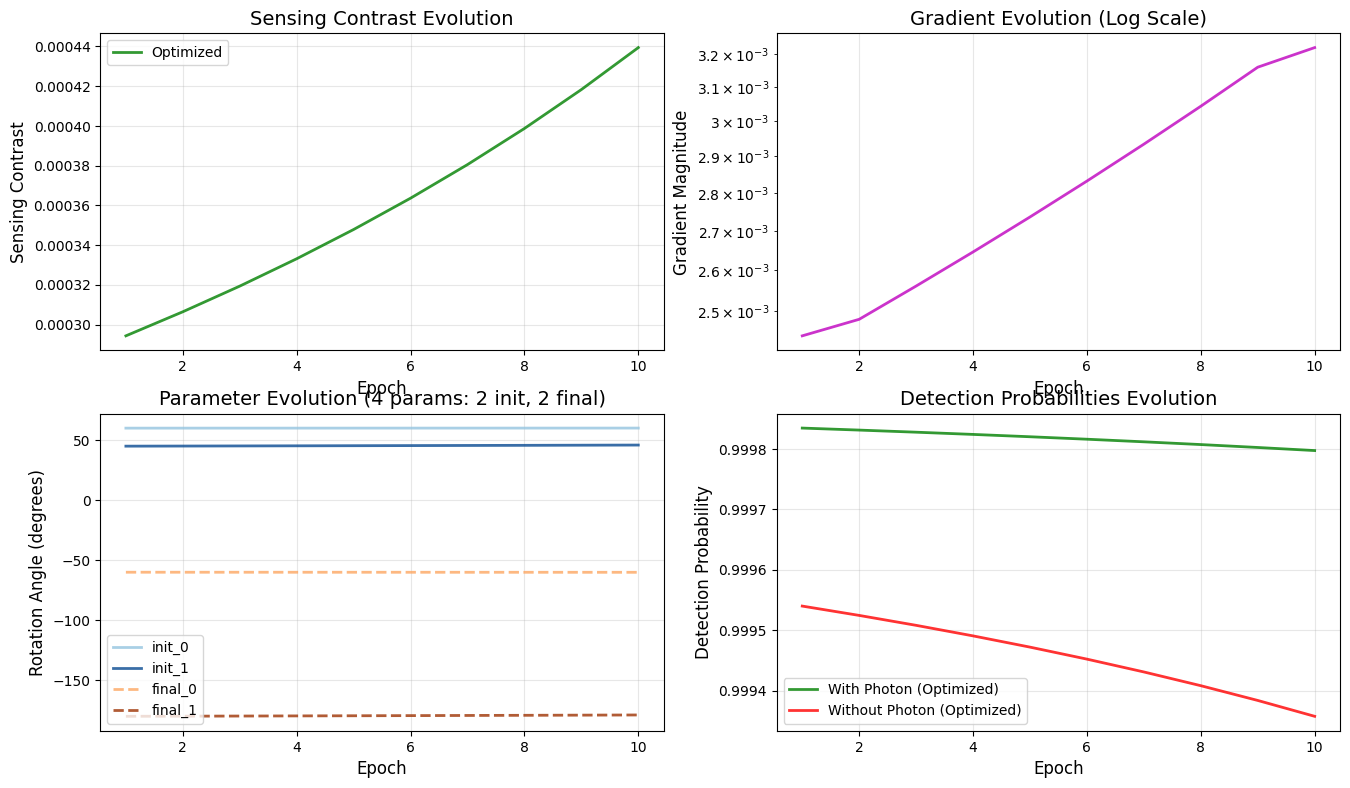

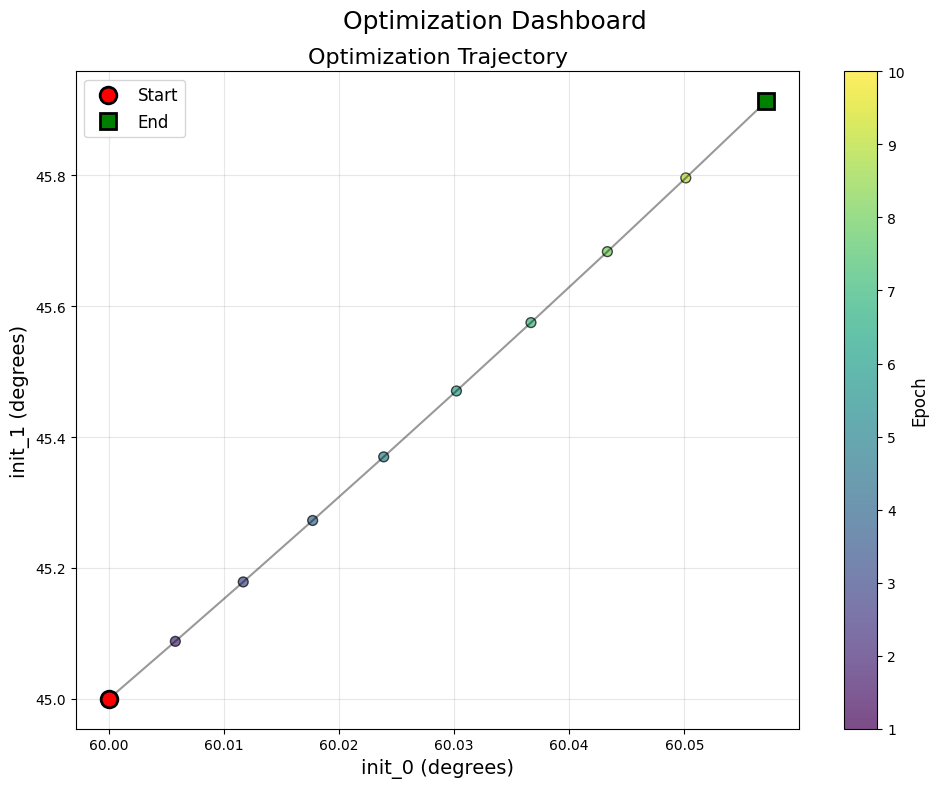

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(16, 14)
)
plt.show()
